# Exercises for Chapter 17: Poststratification and missing-data imputation

In [56]:
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [48]:
prng_builder = bg_ros.PRNGBuilder('Chapter 17: Poststratification and missing-data imputation')

## 17.1, Regression and poststratification

> Section 10.4 presents some models predicting weight from height and other
> variables using survey data in the
> [folder `Earnings`](https://github.com/avehtari/ROS-Examples/tree/master/Earnings/data).
> But these data are not representative of the population. In particular, 62% of
> the respondents in this survey are women, as compared to only 52% of the
> general adult population. We also know the approximate distribution of heights
> in the adult population: normal with mean 63.7 inches and standard deviation 
> 2.7 inches for women, and normal with mean 69.1 inches and standard deviation
> 2.9 inches for men.
>
> (a) Use poststratification to estimate the average weight in the general
>     population, as follows:
> 
> > (i) fit a regression of linear weight on height and sex;
> >
> > (ii) use `posterior_epred` to make predictions for men and women for each
> >     integer value of height from 50 through 80 inches;
> > (iii) poststratify using a  discrete approximation to the normal
> >     distribution for heights given sex, and the known proportion of men and
> >     women in the population.
>
>    Your result should be a set of simulation draws representing the population
>    average weight. Give the median and mad sd of this distribution: this
>    represents your estimate and uncertainty about the population average
>    weight.
>
> (b) Repeat the above steps, this time including the `height:female`
>     interaction in your fitted model before poststratifying.
>
> (c) Repeat (a) and (b), this time performing a regression of log(weight) but
>     still with the goal of estimating average weight in the population, so you
>     will need to exponentiate your predictions in step (ii) before
>     poststratifying.

In [2]:
earn_df = pandas.read_csv('/home/bgawalt/ros/datasets/earnings.csv')[['weight', 'height', 'male']].dropna()
print(bg_ros.dataframe_describe_markdown(earn_df))

|         | weight | height | male
--------- | ------ | ------ | ----
**count** | 1789.00 | 1789.00 | 1789.00
**mean**  | 156.31 | 66.59 | 0.38
**std**   | 34.62 | 3.84 | 0.48
**min**   | 80.00 | 57.00 | 0.00
**25%**   | 130.00 | 64.00 | 0.00
**50%**   | 150.00 | 66.00 | 0.00
**75%**   | 180.00 | 70.00 | 1.00
**max**   | 342.00 | 82.00 | 1.00



### 17.1(a)

In [3]:
# 2-d array; size N x 3;
#   - col 0 is const (intercept)
#   - col 1 is height;
#   - col 2 is gender (1 = male)
census_table = numpy.zeros((2 * (80 - 50 + 1), 3))
prevalence = []
for i, height in enumerate(range(50, 81)):
    # Women's height
    census_table[2 * i, :] = [1, height, 0]
    prevalence.append(
        0.52 * (
            stats.norm.cdf(height + 0.5, loc=63.7, scale=2.7) - 
            stats.norm.cdf(height - 0.5, loc=63.7, scale=2.7)
        )
    )
    census_table[2 * i + 1, :] = [1, height, 1]
    prevalence.append(
        0.48 * (
            stats.norm.cdf(height + 0.5, loc=69.1, scale=2.9) - 
            stats.norm.cdf(height - 0.5, loc=69.1, scale=2.9)
        )
    )
prevalence = numpy.array(prevalence)
print(100 * sum(prevalence))    
print(census_table.shape)
print(census_table.mean(axis=0))

99.9979662790406
(62, 3)
[ 1.  65.   0.5]


In [4]:
weight1_model = bambi.Model('weight ~ height + male', earn_df)
weight1_fit = weight1_model.fit()
print(bg_ros.bambi_markdown(weight1_fit, ['height', 'male']))

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/miniconda3/envs/ros_conda/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, height, male]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 28.70 | 0.48
Intercept | -107.04 | 16.04
height    | 3.89 | 0.25
male      | 11.83 | 1.96



In [5]:
weight1_coefs = bg_ros.bambi_flatten(weight1_fit, ['Intercept', 'height', 'male'])
print(weight1_coefs.keys())
for arr in weight1_coefs.values():
    assert len(arr) == 4000

dict_keys(['Intercept', 'height', 'male'])


In [6]:
weight1_coefs_arr = numpy.zeros((3, 4000))
for i in range(4000):
    weight1_coefs_arr[0, i] = weight1_coefs['Intercept'][i]
    weight1_coefs_arr[1, i] = weight1_coefs['height'][i]
    weight1_coefs_arr[2, i] = weight1_coefs['male'][i]
epreds1 = census_table.dot(weight1_coefs_arr)
weight_preds1 = prevalence.dot(epreds1)

In [7]:
print(f'Mean: {numpy.mean(weight_preds1):} lbs.\nSE: {numpy.std(weight_preds1)} lbs.')

Mean: 156.36247984468878 lbs.
SE: 0.7212678452268153 lbs.


### 17.1(b)

In [8]:
census_table_inter = numpy.zeros((62, 4))
census_table_inter[:, 0:3] = census_table
census_table_inter[:, 3] = census_table[:, 1] * census_table[:, 2]
print(census_table_inter.mean(axis=0))

[ 1.  65.   0.5 32.5]


In [9]:
weight2_model = bambi.Model('weight ~ height + male + height:male', earn_df)
weight2_fit = weight2_model.fit()
print(bg_ros.bambi_markdown(weight2_fit, ['height', 'male', 'height:male']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, height, male, height:male]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


Coef.       | Mean   | s.e.
----------- | ------ | ------
sigma       | 28.60 | 0.49
Intercept   | -62.04 | 21.00
height      | 3.19 | 0.33
male        | -95.63 | 32.13
height:male | 1.59 | 0.47



In [12]:
weight2_coefs = bg_ros.bambi_flatten(weight2_fit, ['Intercept', 'height', 'male', 'height:male'])
print(weight2_coefs.keys())
for arr in weight2_coefs.values():
    assert len(arr) == 4000
weight2_coefs_arr = numpy.zeros((4, 4000))
for i in range(4000):
    weight2_coefs_arr[0, i] = weight2_coefs['Intercept'][i]
    weight2_coefs_arr[1, i] = weight2_coefs['height'][i]
    weight2_coefs_arr[2, i] = weight2_coefs['male'][i]
    weight2_coefs_arr[3, i] = weight2_coefs['height:male'][i]
epreds2 = census_table_inter.dot(weight2_coefs_arr)
weight_preds2 = prevalence.dot(epreds2)

dict_keys(['Intercept', 'height', 'male', 'height:male'])


In [13]:
print(f'Mean: {numpy.mean(weight_preds2):} lbs.\nSE: {numpy.std(weight_preds2)} lbs.')

Mean: 156.21394267343524 lbs.
SE: 0.7268574172671497 lbs.


### 17.1(c)

In [14]:
weight3_model = bambi.Model('log(weight) ~ height + male', earn_df)
weight3_fit = weight3_model.fit()
print(bg_ros.bambi_markdown(weight3_fit, ['height', 'male']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, height, male]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | 0.17 | 0.00
Intercept | 3.37 | 0.10
height    | 0.03 | 0.00
male      | 0.08 | 0.01



In [15]:
weight3_coefs = bg_ros.bambi_flatten(weight3_fit, ['Intercept', 'height', 'male'])
print(weight3_coefs.keys())
for arr in weight3_coefs.values():
    assert len(arr) == 4000
weight3_coefs_arr = numpy.zeros((3, 4000))
for i in range(4000):
    weight3_coefs_arr[0, i] = weight3_coefs['Intercept'][i]
    weight3_coefs_arr[1, i] = weight3_coefs['height'][i]
    weight3_coefs_arr[2, i] = weight3_coefs['male'][i]
epreds3 = numpy.exp(census_table.dot(weight3_coefs_arr))
weight_preds3 = prevalence.dot(epreds3)
print(f'Mean: {numpy.mean(weight_preds3):} lbs.\nSE: {numpy.std(weight_preds3)} lbs.')

dict_keys(['Intercept', 'height', 'male'])
Mean: 154.02240342191806 lbs.
SE: 0.6693952086034013 lbs.


In [16]:
weight4_model = bambi.Model('log(weight) ~ height + male + height:male', earn_df)
weight4_fit = weight4_model.fit()
print(bg_ros.bambi_markdown(weight4_fit, ['height', 'male', 'height:male']))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, height, male, height:male]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


Coef.       | Mean   | s.e.
----------- | ------ | ------
sigma       | 0.17 | 0.00
Intercept   | 3.54 | 0.12
height      | 0.02 | 0.00
male        | -0.33 | 0.20
height:male | 0.01 | 0.00



In [17]:
weight4_coefs = bg_ros.bambi_flatten(weight4_fit, ['Intercept', 'height', 'male', 'height:male'])
print(weight4_coefs.keys())
for arr in weight4_coefs.values():
    assert len(arr) == 4000
weight4_coefs_arr = numpy.zeros((4, 4000))
for i in range(4000):
    weight4_coefs_arr[0, i] = weight4_coefs['Intercept'][i]
    weight4_coefs_arr[1, i] = weight4_coefs['height'][i]
    weight4_coefs_arr[2, i] = weight4_coefs['male'][i]
    weight4_coefs_arr[3, i] = weight4_coefs['height:male'][i]
epreds4 = numpy.exp(census_table_inter.dot(weight4_coefs_arr))
weight_preds4 = prevalence.dot(epreds4)
print(f'Mean: {numpy.mean(weight_preds4):} lbs.\nSE: {numpy.std(weight_preds4)} lbs.')

dict_keys(['Intercept', 'height', 'male', 'height:male'])
Mean: 153.93540727774743 lbs.
SE: 0.6883746475287484 lbs.


## 17.2, Regression and poststratification with fake data

> Repeat the fake-data simulation of Section 17.2, replacing the made-up
> population numbers and the assumption that sex, age, and ethnicity are
> statistically independent in the population, instead using Census numbers for
> the distribution of sex $\times$ age $\times$ education of adults in the
> United States. You can keep the same 32 demographic categories; just use the
> actual numbers.
>
> (a) Compare your newly created vector `poststrat$N` to the vector
>     `poststrat$N` constructed in Section 17.2.
>
> (b) You have done a fake-data simulation, so you can compare inferences to the
>     true values. Your baseline is the true population mean of the outcome
>     under your model, so compute that first.
>
> (c) Compute the sample mean in your simulated data, $y$, and the corresponding
>     standard error based on the (incorrect) binomial model corresponding to
>     independent sampling with equal probabilities. Compare these to the true
>     population mean.
>
> (d) Examine the posterior estimate and standard error obtained by
>     poststratification

In [91]:
rng = prng_builder.new('17.2, Regression and poststratification with fake data')

In [92]:
census_df = bg_ros.census_df()
census_df.head()

,race,age,male,counts
0,white,18-24,1,11605839
1,white,25-44,1,33979924
2,white,45-64,1,31853342
3,white,65+,1,23123173
4,white,18-24,0,11019899


In [93]:
counts17_2 = []  # The counts simulated in Section 17.2
age_lookup = {
    '18-24': 0.2,
    '25-44': 0.25,
    '45-64': 0.3,
    '65+': 0.25,
}
for _, row in census_df.iterrows():
    num = 250e6
    sex = 0.48 if row['male'] == 1 else 0.52
    race = 0.7 if row['race'] == 'white' else 0.1
    age = age_lookup[row['age']]
    counts17_2.append(num * sex * race * age)
census_df['counts_17_2'] = counts17_2

Text(0, 0.5, 'Fake Sec 17.2 Count (Millions)')

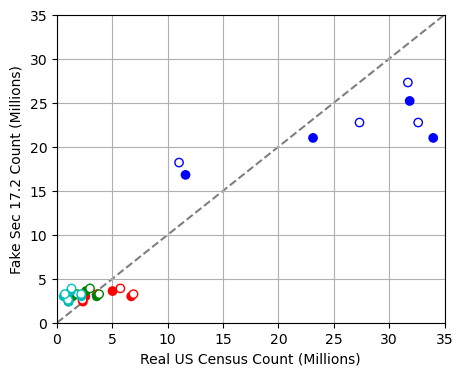

In [94]:
race_color = {
    'white': 'b',
    'black': 'r',
    'asian': 'g',
    'other': 'c',
}
colors = [race_color[race] for race in census_df['race']]
fills = [colors[i] if male == 1 else 'w'
         for i, male in enumerate(census_df['male'])]
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.scatter(
    census_df['counts'] / 1e6,
    census_df['counts_17_2'] / 1e6,
    c=fills,
    edgecolors=colors,
)
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(0, 35)
ax.set_ylim(0, 35)
ax.plot([0, 35], [0, 35], 'k--', alpha=0.5, zorder=0)
ax.set_xlabel('Real US Census Count (Millions)')
ax.set_ylabel('Fake Sec 17.2 Count (Millions)')

Text(0, 0.5, 'Fake Sec 17.2 Count (Log2)')

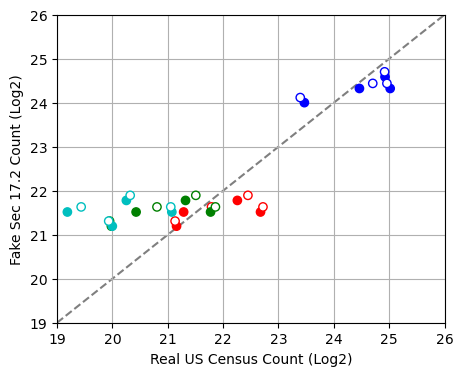

In [95]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.scatter(
    numpy.log2(census_df['counts']),
    numpy.log2(census_df['counts_17_2']),
    c=fills,
    edgecolors=colors,
)
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(19, 26)
ax.set_ylim(19, 26)
ax.plot([19, 26], [19, 26], 'k--', alpha=0.5, zorder=0)
ax.set_xlabel('Real US Census Count (Log2)')
ax.set_ylabel('Fake Sec 17.2 Count (Log2)')

In [96]:
race_resp_coef = {
    'white': (1.0, 0),
    'black': (0.8, 0.6),
    'asian': (0.7, 0.3),
    'other': (0.6, 0.3),
}
age_resp_coef = {
    '18-24': (1, 0),
    '25-44': (1.2, -0.2),
    '45-64': (1.6, -0.3),
    '65+': (2.5, -0.4),
}

In [97]:
# True baseline:
num_yes = 0
coef_intercept = 0.6
for _, row in census_df.iterrows():
    _, rc = race_resp_coef[row['race']]
    _, ac = age_resp_coef[row['age']]
    sc = -0.2 * row['male']
    py = special.expit(coef_intercept + rc + ac + sc)
    num_yes += py * row['counts']
print(round(num_yes), '/', sum(census_df['counts']), f'={100 * num_yes / sum(census_df["counts"]): 0.1f}' + '%')

156768438 / 266978268 = 58.7%


In [98]:
resps = []    
triples = []
resp_base = 0.1
for _, row in census_df.iterrows():
    triple = (row['race'], row['age'], row['male'])
    rr, _ = race_resp_coef[row['race']]
    ar, _ = age_resp_coef[row['age']]
    sr, _ = (0.8, -0.2) if row['male'] == 1 else (1, 0)
    p_resp = (resp_base * rr * ar * sr)
    resps.append(round(row['counts'] * p_resp))
    triples.append(triple)
resps = numpy.array(resps) / sum(resps)
people = rng.choice(triples, size=1000, replace=True, p=resps)

In [99]:
ys = []
coef_intercept = 0.6
for race, age, male in people:
    _, rc = race_resp_coef[race]
    _, ac = age_resp_coef[age]
    assert male == '1' or male == '0'
    sc = -0.2 if male == '1' else 0
    py = special.expit(coef_intercept + rc + ac + sc)
    ys.append(1 if rng.random() < py else 0)    

In [100]:
p = numpy.mean(ys)
print(f'Mean: {100 * p: 0.1f}' + '%')
print(f'SE: {100 * numpy.sqrt(p * (1 - p) / 1000): 0.1f} pct-pts')

Mean:  58.3%
SE:  1.6 pct-pts


In [101]:
sample_df = pandas.DataFrame(
    data = {
        'race': [r for r, _, _ in people],
        'age': [a for _, a, _ in people],
        'male': [int(m) for _, _, m in people],
        'y': ys,
    })
sample_df.describe()

,male,y
count,1000.000000,1000.00000
mean,0.432000,0.58300
std,0.495602,0.49331
min,0.000000,0.00000
25%,0.000000,0.00000
50%,0.000000,1.00000
75%,1.000000,1.00000
max,1.000000,1.00000


In [102]:
census_model = bambi.Model("y['1'] ~ race + age + male", sample_df, family='bernoulli')
census_fit = census_model.fit()

Modeling the probability that y==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, race, age, male]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [103]:
print(bg_ros.bambi_markdown(
    census_fit,
    [
        'race[black]', 'race[other]', 'race[white]',
        'age[25-44]', 'age[45-64]', 'age[65+]',
        'male',
    ]
))

Coef.       | Mean   | s.e.
----------- | ------ | ------
sigma       | nan | nan
Intercept   | 1.04 | 0.38
race[black] | 0.03 | 0.33
race[other] | 0.34 | 0.58
race[white] | -0.30 | 0.28
age[25-44]  | 0.05 | 0.28
age[45-64]  | -0.40 | 0.27
age[65+]    | -0.44 | 0.27
male        | -0.38 | 0.14



In [107]:
census_model.predict(census_fit, data=census_df, kind='response')
preds_df = census_fit.posterior.mean(dim=["chain", "draw"])["p"].to_dataframe()
k = 0
for pi, ci in zip(preds_df['p'], census_df['counts']):
    k += (pi * ci)
print(k / sum(census_df['counts']))

0.602567820337199
